In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [42]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Ostfalia Hochschule für Angewandte Wissenschaften' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/01bk10867' -- 'Ostfalia Hochschule für Angewandte Wissenschaften'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [43]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Wolfe...",https://openalex.org/W4281940252
1,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Wolfe...",https://openalex.org/W4281940252
2,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Department of Computer Science, Ostfalia Unive...",https://openalex.org/W4292676328
3,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Department of Computer Science, Ostfalia Unive...",https://openalex.org/W4292676328
4,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University,Faculty of Mechanical Engi...",https://openalex.org/W4321061960


In [186]:
MAPPING_DICT = {
    'Fakultät Bau-Wasser-Boden': ['bau-wasser-boden', 'civil engineering', 'enviro(n)?mental engineering', 'civil department'],
    'Fakultät Handel und Soziale Arbeit': ['trade and social work'],
    'Fakultät Verkehr-Sport-Tourismus-Medien': ['media management', 'tourism-media', 'public communication', 'regionalforschung'],
    'Fakultät Elektro- und Informationstechnik': ['electrical (engineering|energy|systems)'],
    'Fakultät Informatik': ['information engineering', 'informatik', 'computer science', 'robotics lab', 'distributed systems', 
                            'faculty for( applied)? informatics', 'applied informatics'],
    'Fakultät Maschinenbau': ['mechatroni(k|cs)', 'mechanical engineering', 'production technolog(y|ies)', 'maschinenbau'],
    'Fakultät Recht': ['economic law', '(bels)', 'institut für recht', 'brunswick european law'],
    'Fakultät Soziale Arbeit': ['soziale(n)? arbeit', 'social work'],
    'Fakultät Versorgungstechnik': ['biotechnology', 'kommunikationssysteme', 'supply (engineering|technology)', 'versorgungstechnik'],
    'Fakultät Fahrzeugtechnik': ['recycling', 'vehicle', 'automotive engineering', 'fahrzeugbau'],
    'Fakultät Gesundheitswesen': ['health(\s)?(care|science|service)', 'gesundheit'],
    'Fakultät Wirtschaft': ['fakultät wirtschaft', 'faculty of business', 'business administration']
}

In [187]:
with open('./mapping_tables_fak/ostfalia.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [188]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [189]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [190]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Wolfe...",https://openalex.org/W4281940252
1,None,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Wolfe...",https://openalex.org/W4281940252
2,Fakultät Informatik,Ostfalia Hochschule für Angewandte Wissenschaften,"Department of Computer Science, Ostfalia Unive...",https://openalex.org/W4292676328
3,Fakultät Informatik,Ostfalia Hochschule für Angewandte Wissenschaften,"Department of Computer Science, Ostfalia Unive...",https://openalex.org/W4292676328
4,Fakultät Maschinenbau,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University,Faculty of Mechanical Engi...",https://openalex.org/W4321061960
...,...,...,...,...
769,Fakultät Bau-Wasser-Boden,Ostfalia Hochschule für Angewandte Wissenschaften,Faculty of Civil and Environmental Engineering...,https://openalex.org/W3017778212
770,None,Ostfalia Hochschule für Angewandte Wissenschaften,ZWIRN-Research Center/Ostfalia University of A...,https://openalex.org/W3095498078
771,None,Ostfalia Hochschule für Angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaf...,https://openalex.org/W3095498078
772,Fakultät Soziale Arbeit,Ostfalia Hochschule für Angewandte Wissenschaften,"Professur Soziologie für die Soziale Arbeit, F...",https://openalex.org/W4241637348


In [191]:
df_with_inst[(df_with_inst.fak_name.isnull()) & df_with_inst.raw_affiliation_string.str.contains('ostfalia', case=False, regex=False)].raw_affiliation_string.unique()

array(['Ostfalia University of Applied Sciences, Wolfenbüttel, Germany',
       'Ostfalia University of Applied Sciences, Salzdahlumer Str. 46/48, 38302 Wolfenbuettel, Germany, --- Select a Country ---',
       'Ostfalia Hochschule für angewandte Wissenschaften (Germany)',
       'Ostfalia University of Applied Sciences',
       'Ostfalia University of applied sciences, Salzdahlumer Straße 46/48, 38302 Wolfenbüttel, Germany',
       'Ostfalia Hochschule für angewandte Wissenschaften, Wolfsburg, Deutschland',
       'Ostfalia Hochschule für angewandte Wissenschaften - Hochschule Braunschweig/Wolfenbüttel, Wolfsburg, Deutschland',
       'Ostfalia Hochschule, Wolfsburg, Deutschland',
       'Ostfalia Hochschule',
       'Ostfalia Hochschule für angewandte Wissenschaften',
       'Ostfalia University of Applied Sciences, Herbert-Meyer-Straße 7, 29556, Suderburg, Germany',
       'Ostfalia -Hochschule Braun-schweig/Wolfenbüttel.',
       'Ostfalia Hochschule für angewandte Wissenschaften, 

In [192]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fakultät Bau-Wasser-Boden,10
1,Fakultät Elektro- und Informationstechnik,53
2,Fakultät Fahrzeugtechnik,12
3,Fakultät Gesundheitswesen,66
4,Fakultät Handel und Soziale Arbeit,6
5,Fakultät Informatik,170
6,Fakultät Maschinenbau,93
7,Fakultät Recht,22
8,Fakultät Soziale Arbeit,31
9,Fakultät Verkehr-Sport-Tourismus-Medien,13


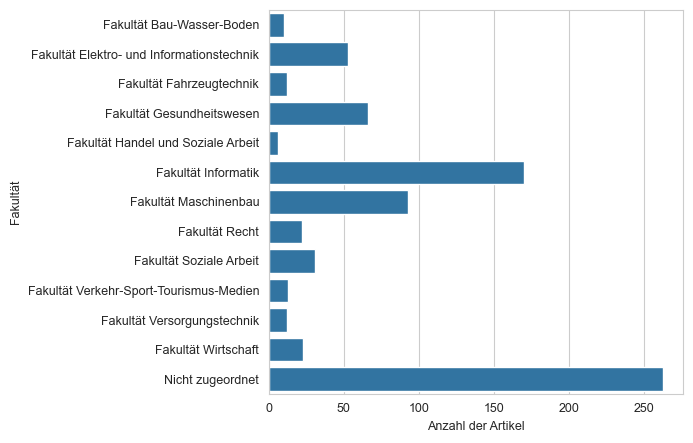

In [193]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [194]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6602067183462532

In [281]:
MAPPING_DICT_DEPT = {
    'Fakultät Verkehr-Sport-Tourismus-Medien': {
        'Institut für Mediendesign (IMD)': ['mediendesign'],
        'Institut für Medienmanagement': ['medienmanagement', 'media management'],
        'Institut für Verkehrsmanagement': ['verkehrsmanagement'],
        'Institut für Öffentliche Kommunikation (IÖK)': ['öffentliche kommunikation', 'public communication'],
    },
    'Fakultät Elektro- und Informationstechnik': {
        'Institut für Elektrische Anlagen und Automatisierungstechnik (IfEA)': ['automatisierungstechnik', 'process engineering', 
                                                                                'automation (technology|system)'
                                                                               ],
    },
    'Fakultät Informatik': {
        'Institut für Information Engineering (IIE)': ['information engineering'],
        'Institut für Medieninformatik und Online-Lehre (IMI)': ['medieninformatik'],
        'Institut für Software Engineering (ISE)': ['software engineering'],
        'Institut für Verteilte Systeme (IVS)': ['verteilte systeme', 'distributed system'],
    },
    'Fakultät Maschinenbau': {
        'Institut für Konstruktion und Angewandten Maschinenbau': ['konstruktion', 'design and applied'],
        'Institut für Mechatronik': ['mechatroni(k|c)'],
        'Institut für Produktionstechnik': ['produktionstechnik', 'production technolog(y|ies)'],
    },
    'Fakultät Recht': {
        'Institut für Europäisches und Internationales Wirtschaftsrecht': ['international economic law'],
        'Institut für Finanzen, Steuern und Recht': ['finanzen', 'finance'],
        #'Institut für Geistiges Eigentum, Recht und Wirtschaft in der Informationsgesellschaft': [],
        'Institut für Personalmanagement und Recht': ['personalmanagement'],
    },
    'Fakultät Soziale Arbeit': {
        #'Institut für angewandte Rechts- und Sozialforschung (IRS)': [],
        #'Professur Digitaliät in Rehabilitation und Teilhabe': [],
    },
    'Fakultät Versorgungstechnik': {
        'Institut für Biotechnologie und Umweltforschung (IBU)': ['biotechnolog(ie|y)'],
        #'Institut für energieoptimierte Systeme': [],
        #'Institut für Technische Unternehmensführung': [],
        'Institut für Kommunikationssysteme und Technologien': ['kommunikationssysteme'],
    },
    'Fakultät Fahrzeugtechnik': {
        'Institut für Fahrzeugbau Wolfsburg (IFBW)': ['fahrzeugbau', 'vehicle body'],
        #'Institut für Fahrzeuginformatik und Fahrzeugelektronik': [],
        'Institut für Recycling': ['recycling'],
    }
}

In [282]:
with open('./mapping_tables_dept/ostfalia.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [283]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [284]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fakultät Fahrzeugtechnik')

In [285]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:]

array(['Ostfalia University of Applied Sciences,Faculty of Automotive Engineering,Wolfsburg,Germany',
       'Faculty of Automotive Engineering, Ostfalia University of Applied Sciences, Kleiststraße 26, 38440 Wolfsburg, Germany',
       'Faculty of Automotive Engineering, Ostfalia University of Applied Sciences, Wolfsburg, Germany',
       'Faculty of Automotive Engineering, Ostfalia University of Applied Sciences, Kleiststr. 14-16, D-38440 Wolfsburg, Germany'],
      dtype=object)

In [286]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Institut für Fahrzeugbau Wolfsburg (IFBW),2
1,Institut für Recycling,5
2,NaN,5


In [287]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
46,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institut für Fahrzeugbau (IFBW), Ostfalia Univ...",https://openalex.org/W4214680642,Institut für Fahrzeugbau Wolfsburg (IFBW)
88,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences,Facult...",https://openalex.org/W4313263318,None
89,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences,Facult...",https://openalex.org/W4313263318,None
137,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Automotive Engineering, Ostfalia Un...",https://openalex.org/W4392709861,None
319,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute for Recycling, Ostfalia University o...",https://openalex.org/W4406680069,Institut für Recycling
348,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Insti...",https://openalex.org/W4385955985,Institut für Recycling
349,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Insti...",https://openalex.org/W4385955985,Institut für Recycling
397,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,Vehicle Body Engineering and Lightweight Desig...,https://openalex.org/W4416367789,Institut für Fahrzeugbau Wolfsburg (IFBW)
507,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute of Recycling, Ostfalia University of...",https://openalex.org/W3138286370,Institut für Recycling
524,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Automotive Engineering, Ostfalia Un...",https://openalex.org/W3137715126,None
